# Progressão Aritmética

**Módulo:** 03 – Progressões, Matrizes e Sistemas Lineares

**Pré-requisitos:** noção de sequência, termo geral e lei de formação explícita/recursiva, vista em [`0301a_sequencias.ipynb`](0301a_sequencias.ipynb); e a função afim (primeiro grau), vista em [`0107a_funcoes_primeiro_grau.ipynb`](../01_conjuntos_e_funcoes/0107a_funcoes_primeiro_grau.ipynb)

**Objetivos de aprendizagem:**
- Reconhecer uma PA e classificá-la quanto à razão (crescente, decrescente ou constante).
- Encontrar o termo geral de uma PA e usá-lo para interpolar meios aritméticos entre dois números.
- Calcular a soma dos termos de uma PA finita.
- Relacionar a PA com a função afim e com contextos reais de crescimento linear.

**Tempo estimado:** 60 a 75 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/03_progressoes_matrizes_e_sistemas_lineares/0302a_progressao_aritmetica.ipynb)

📖 **Leitura complementar:** [Progressão aritmética](https://pt.wikipedia.org/wiki/Progress%C3%A3o_aritm%C3%A9tica)

## A lenda do jovem Gauss

Conta-se que, por volta de 1785, um professor decidiu manter sua turma de crianças ocupada por um bom tempo: somar todos os números de 1 a 100. Mal ele tinha terminado de passar o problema no quadro, um garoto de 9 anos chamado **Carl Friedrich Gauss** já tinha a resposta: **5050**.

Ele não somou 1 + 2 + 3 + ... um por um. Encontrou um atalho — e esse atalho é exatamente a ferramenta que vamos construir neste notebook: a soma dos termos de uma **progressão aritmética**.

**Antes de continuar, pense um pouco:** como você somaria 1 + 2 + ... + 100 rapidamente, sem passar minutos somando termo a termo? Guarde sua ideia — vamos revelar o truque de Gauss (e generalizá-lo) na seção de Soma, mais adiante.

🕵️ **Curiosidade histórica:** essa sequência de números de 1 a 100 é, ela mesma, uma progressão aritmética de razão 1 — o caso mais simples possível. Gauss cresceria para se tornar um dos maiores matemáticos da história, apelidado de "Príncipe da Matemática". Veja mais em [Carl Friedrich Gauss](https://pt.wikipedia.org/wiki/Carl_Friedrich_Gauss).

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


def gerar_pa(a1: float, r: float, n: int) -> np.ndarray:
    """Gera os n primeiros termos de uma PA de primeiro termo a1 e razão r."""
    indices = np.arange(1, n + 1)
    return a1 + (indices - 1) * r

## 1. O que é uma Progressão Aritmética

Olhe para a sequência (2, 5, 8, 11, 14, ...). Repare que a diferença entre um termo e o anterior é sempre a mesma: 5 − 2 = 3, 8 − 5 = 3, 11 − 8 = 3. Uma sequência assim é uma **progressão aritmética** (PA).

📌 **Definição formal:** uma **progressão aritmética** é uma sequência (aₙ) em que a diferença entre cada termo (a partir do segundo) e o termo anterior é sempre a mesma constante **r**, chamada de **razão** da PA:

$$a_n - a_{n-1} = r \quad \text{para todo } n \geq 2$$

Isso é o mesmo que dizer que a PA tem **lei de formação recursiva** aₙ = aₙ₋₁ + r, com a₁ dado — exatamente a ideia de lei recursiva que vimos em [`0301a_sequencias.ipynb`](0301a_sequencias.ipynb), aplicada ao caso mais simples possível: somar sempre a mesma constante.

📎 **Conexão:** uma PA é uma sequência (no sentido estudado no notebook anterior) com uma restrição extra — a razão constante. Toda PA é sequência, mas nem toda sequência é PA (por exemplo, Fibonacci não é).

Vamos representar a PA (2, 5, 8, 11, ...) de três formas: algébrica (a lei recursiva), numérica (tabela) e gráfica (pontos).

,n,a_n,a_n - a_(n-1)
0,1,2,NaN
1,2,5,3.0
2,3,8,3.0
3,4,11,3.0
4,5,14,3.0
5,6,17,3.0
6,7,20,3.0
7,8,23,3.0


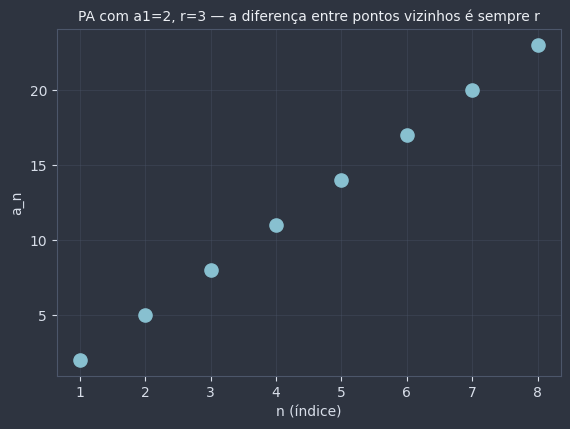

In [2]:
a1_exemplo = 2
r_exemplo = 3
n_exemplo = 8

termos_exemplo = gerar_pa(a1_exemplo, r_exemplo, n_exemplo)
indices_exemplo = np.arange(1, n_exemplo + 1)

diferencas = np.diff(termos_exemplo)
tabela_exemplo = pd.DataFrame({
    "n": indices_exemplo,
    "a_n": termos_exemplo,
    "a_n - a_(n-1)": [None] + list(diferencas),
})
display(tabela_exemplo)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.scatter(indices_exemplo, termos_exemplo, s=90, color=COR_PONTO, zorder=3)
ax.set_xlabel("n (índice)", color=NORD_TEXTO_SEC)
ax.set_ylabel("a_n", color=NORD_TEXTO_SEC)
ax.set_xticks(indices_exemplo)
ax.set_title(f"PA com a1={a1_exemplo}, r={r_exemplo} — a diferença entre pontos vizinhos é sempre r", color=NORD_TEXTO, fontsize=10)
plt.show()

**Pergunta de checagem:** na tabela acima, por que a primeira linha da coluna "a_n − a_(n−1)" fica vazia?

🎯 **Aplicação prática:** o número de degraus que você sobe é uma PA de razão 1 (cada degrau soma 1 à altura); uma escada com degraus de altura constante também gera uma PA de alturas acumuladas, com razão igual à altura de cada degrau.

## 2. Classificação quanto à razão

Toda PA se encaixa em um destes três tipos, dependendo só do sinal da razão r:

- **Crescente**: r > 0 — cada termo é maior que o anterior.
- **Decrescente**: r < 0 — cada termo é menor que o anterior.
- **Constante**: r = 0 — todos os termos são iguais.

⚠️ **Erro comum:** achar que uma PA só é "decrescente" se os termos forem negativos. Isso é falso — o que define crescente/decrescente é o **sinal da razão**, não o sinal dos termos. Uma PA pode começar com termos bem positivos e ainda assim ser decrescente, se r < 0.

a1=   1, r=  4 -> termos positivos? True | classificação: crescente
a1= 100, r= -7 -> termos positivos? True | classificação: decrescente
a1=   5, r=  0 -> termos positivos? True | classificação: constante


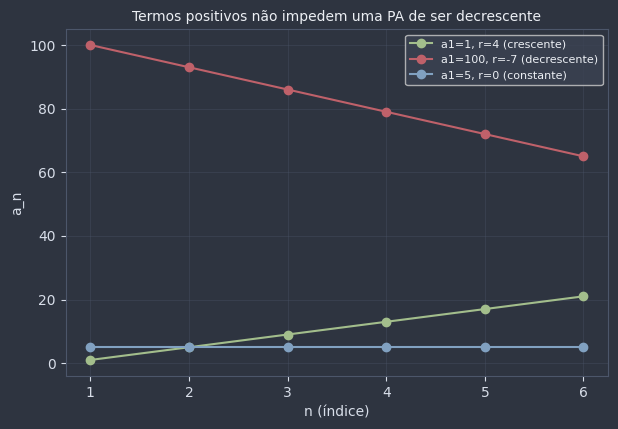

In [3]:
def classificar_pa(r: float) -> str:
    """Classifica uma PA em crescente, decrescente ou constante, a partir da razão."""
    if r > 0:
        return "crescente"
    elif r < 0:
        return "decrescente"
    return "constante"


# Contraexemplo do erro comum: termos positivos, mas PA decrescente (r < 0)
exemplos = [
    {"a1": 1, "r": 4, "n": 6},
    {"a1": 100, "r": -7, "n": 6},
    {"a1": 5, "r": 0, "n": 6},
]
cores_exemplos = [COR_DESTAQUE, COR_ALERTA, COR_SECUNDARIA]

fig, ax = plt.subplots(figsize=(7, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)

for exemplo, cor in zip(exemplos, cores_exemplos, strict=True):
    termos = gerar_pa(exemplo["a1"], exemplo["r"], exemplo["n"])
    indices = np.arange(1, exemplo["n"] + 1)
    classificacao = classificar_pa(exemplo["r"])
    ax.plot(indices, termos, "o-", color=cor, label=f"a1={exemplo['a1']}, r={exemplo['r']} ({classificacao})")
    print(f"a1={exemplo['a1']:>4}, r={exemplo['r']:>3} -> termos positivos? {all(t > 0 for t in termos)} | classificação: {classificacao}")

ax.set_xlabel("n (índice)", color=NORD_TEXTO_SEC)
ax.set_ylabel("a_n", color=NORD_TEXTO_SEC)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8)
ax.set_title("Termos positivos não impedem uma PA de ser decrescente", color=NORD_TEXTO, fontsize=10)
plt.show()

**Pergunta de checagem:** a PA do exemplo com a1=100 e r=−7 tem todos os termos positivos nas primeiras rodadas, mas é classificada como decrescente. O que aconteceria com essa PA se ela continuasse por muitos termos?

## 3. Notações especiais: PA de 3 e de 4 termos

Quando um problema envolve **poucos termos** de uma PA (3 ou 4) e pede para descobrir esses termos a partir de informações como soma e produto, existe uma notação que simplifica muito as contas: centralizar a PA em uma incógnita **x**.

📌 **PA de 3 termos**, centrada em x, com razão r:

$$(x - r,\ x,\ x + r)$$

📌 **PA de 4 termos**, centrada entre os dois termos do meio, com razão r:

$$(x - 3r,\ x - r,\ x + r,\ x + 3r)$$

A vantagem: somando os 3 termos, os "±r" se cancelam e sobra 3x — o que já revela x direto a partir da soma, sem precisar resolver um sistema. O mesmo vale para os 4 termos (soma = 4x).

Vamos usar essa ideia para resolver: **três números em PA têm soma 24 e produto 384. Quais são eles?**

In [4]:
soma_dada = 24
produto_dado = 384

# Com a notacao (x - r, x, x + r): soma = 3x, entao x = soma / 3
x = soma_dada / 3
print(f"soma = 3x  ->  x = {x}")

# produto = (x - r) * x * (x + r) = x * (x^2 - r^2) = produto_dado
# entao r^2 = x^2 - produto_dado / x
r_quadrado = x**2 - produto_dado / x
r = math.sqrt(r_quadrado)
print(f"r^2 = x^2 - produto/x = {r_quadrado}  ->  r = {r}")

numeros = (x - r, x, x + r)
print(f"os três números em PA: {numeros}")
print(f"conferindo: soma = {sum(numeros)}, produto = {numeros[0] * numeros[1] * numeros[2]:.0f}")

soma = 3x  ->  x = 8.0
r^2 = x^2 - produto/x = 16.0  ->  r = 4.0
os três números em PA: (4.0, 8.0, 12.0)
conferindo: soma = 24.0, produto = 384


📎 **Conexão:** essa notação centralizada é um truque algébrico, não um conceito novo de PA — é só uma forma mais conveniente de escrever os mesmos termos aₙ = a₁ + (n−1)r, útil quando o número de termos é pequeno e conhecido de antemão.

**Pergunta de checagem:** por que a notação centralizada (x−r, x, x+r) não é tão útil quando a PA tem, digamos, 20 termos?

## 4. Fórmula do termo geral

A lei recursiva aₙ = aₙ₋₁ + r é ótima para entender a PA, mas para chegar direto ao termo 100 ela obriga a calcular os 99 anteriores. Precisamos de uma **lei explícita**.

Pense assim: para ir de a₁ até aₙ, você dá **n − 1 passos**, cada um de tamanho r:

$$a_1 \xrightarrow{+r} a_2 \xrightarrow{+r} a_3 \xrightarrow{+r} \cdots \xrightarrow{+r} a_n$$

Como são n − 1 passos de tamanho r a partir de a₁:

📌 **Fórmula do termo geral:**

$$a_n = a_1 + (n - 1) \cdot r$$

🕹️ **Widget interativo:** ajuste a₁, r e n e veja o termo aₙ sendo calculado e destacado sobre o restante da PA.

In [5]:
def explorar_termo_geral(a1: float, r: float, n: int) -> None:
    n_fundo = max(n + 3, 12)
    indices_fundo = np.arange(1, n_fundo + 1)
    termos_fundo = gerar_pa(a1, r, n_fundo)
    termo_n = a1 + (n - 1) * r

    fig, ax = plt.subplots(figsize=(7, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.scatter(indices_fundo, termos_fundo, s=50, color=NORD_LINHA, zorder=2)
    ax.scatter([n], [termo_n], s=160, color=COR_ALERTA, zorder=4)
    ax.set_xlabel("n (índice)", color=NORD_TEXTO_SEC)
    ax.set_ylabel("a_n", color=NORD_TEXTO_SEC)
    ax.set_title(f"a_{n} = {a1} + ({n}-1)·{r} = {termo_n:g}", color=NORD_TEXTO, fontsize=11)
    plt.show()


widgets.interact(
    explorar_termo_geral,
    a1=widgets.FloatSlider(value=1.0, min=-10.0, max=10.0, step=1.0, description="a1:"),
    r=widgets.FloatSlider(value=2.0, min=-5.0, max=5.0, step=0.5, description="r:"),
    n=widgets.IntSlider(value=5, min=1, max=15, step=1, description="n:"),
)

interactive(children=(FloatSlider(value=1.0, description='a1:', max=10.0, min=-10.0, step=1.0), FloatSlider(va…

<function __main__.explorar_termo_geral(a1: float, r: float, n: int) -> None>

📎 **Conexão:** essa fórmula é a versão explícita da mesma PA que definimos de forma recursiva no Bloco 1 — as duas leis (aₙ = aₙ₋₁ + r e aₙ = a₁ + (n−1)r) descrevem exatamente a mesma sequência, do mesmo jeito que vimos em [`0301a_sequencias.ipynb`](0301a_sequencias.ipynb) que uma sequência pode ter mais de uma lei de formação equivalente.

**Pergunta de checagem:** se você conhece a₁ e r, quantas "somas de r" você precisa fazer para chegar em a₅₀? E em a₁?

## 5. Interpolação aritmética

**Interpolar k meios aritméticos** entre dois números dados a₁ e aₙ significa encontrar k números que, junto com a₁ e aₙ, formam uma PA.

Se vamos inserir k meios entre a₁ e aₙ, a PA final tem n = k + 2 termos (os 2 extremos + os k meios). Usando a fórmula do termo geral com esse n:

$$a_n = a_1 + (n - 1) \cdot r \quad \Longrightarrow \quad r = \frac{a_n - a_1}{n - 1} = \frac{a_n - a_1}{k + 1}$$

Ou seja: basta calcular r a partir dos dois extremos e do número de termos, e depois gerar a PA inteira.

**Exemplo:** interpolar 5 meios aritméticos entre 3 e 27.

In [6]:
def interpolar_meios_aritmeticos(a1: float, an: float, k: int) -> np.ndarray:
    """Interpola k meios aritméticos entre a1 e an, retornando a PA completa (n = k + 2 termos)."""
    n = k + 2
    r = (an - a1) / (n - 1)
    return gerar_pa(a1, r, n)


pa_interpolada = interpolar_meios_aritmeticos(a1=3, an=27, k=5)
print(f"PA completa (extremos + meios): {pa_interpolada}")
print(f"apenas os 5 meios aritméticos: {pa_interpolada[1:-1]}")

PA completa (extremos + meios): [ 3.  7. 11. 15. 19. 23. 27.]
apenas os 5 meios aritméticos: [ 7. 11. 15. 19. 23.]


**Pergunta de checagem:** se a₁ e aₙ estão fixos e você quer que a PA final tenha exatamente 10 termos, quantos meios aritméticos k precisa interpolar entre eles?

## 6. Soma dos termos de uma PA finita

Hora de voltar ao gancho: como Gauss somou 1 + 2 + ... + 100 tão rápido?

A ideia é **emparelhar o primeiro termo com o último, o segundo com o penúltimo**, e assim por diante:

$$\underbrace{1 + 100}_{101} \quad \underbrace{2 + 99}_{101} \quad \underbrace{3 + 98}_{101} \quad \cdots \quad \underbrace{50 + 51}_{101}$$

São 50 pares, cada um somando **sempre 101** (primeiro + último). Então a soma total é 50 × 101 = 5050 — exatamente a resposta de Gauss, sem somar termo a termo!

cada par soma 101, e há 50 pares
soma de Gauss (pareando): 5050
conferindo com a soma direta: 5050


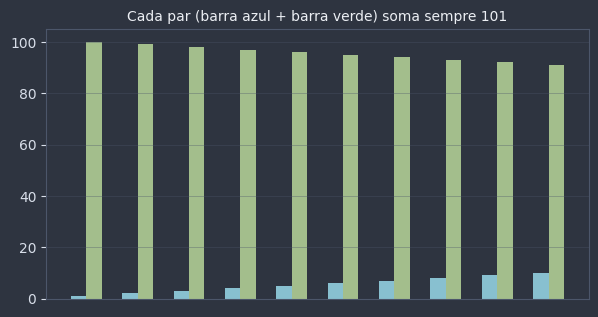

In [7]:
n_gauss = 100
primeiro, ultimo = 1, 100
soma_por_par = primeiro + ultimo
quantidade_pares = n_gauss // 2

soma_gauss = quantidade_pares * soma_por_par
print(f"cada par soma {soma_por_par}, e há {quantidade_pares} pares")
print(f"soma de Gauss (pareando): {soma_gauss}")
print(f"conferindo com a soma direta: {sum(range(1, 101))}")

# Visualizando os pares (primeiros 10 pares, para não poluir o gráfico)
fig, ax = plt.subplots(figsize=(7, 3.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
for i in range(10):
    ax.bar([i - 0.15], [i + 1], width=0.3, color=COR_PONTO)
    ax.bar([i + 0.15], [n_gauss - i], width=0.3, color=COR_DESTAQUE)
ax.set_title("Cada par (barra azul + barra verde) soma sempre 101", color=NORD_TEXTO, fontsize=10)
ax.set_xticks([])
plt.show()

📌 **Fórmula da soma:** esse truque de Gauss funciona para **qualquer** PA finita, não só para 1, 2, ..., 100. Somando o primeiro termo com o último, o segundo com o penúltimo, etc., cada par sempre soma a₁ + aₙ, e há n/2 pares. Isso dá a **fórmula da soma dos n primeiros termos de uma PA**:

$$S_n = \frac{(a_1 + a_n) \cdot n}{2}$$

(a fórmula funciona mesmo quando n é ímpar, sobrando um termo central sem par — a álgebra por trás garante o resultado igual.)

🕹️ **Widget interativo:** mexa no slider de n e veja a soma acumulada Sₙ crescer, termo a termo, para uma PA de a₁ e r à sua escolha.

In [8]:
def explorar_soma_pa(a1: float, r: float, n: int) -> None:
    termos = gerar_pa(a1, r, n)
    indices = np.arange(1, n + 1)
    soma_acumulada = np.cumsum(termos)
    soma_formula = (a1 + termos[-1]) * n / 2

    fig, ax = plt.subplots(figsize=(7, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.bar(indices, soma_acumulada, color=COR_PONTO)
    ax.set_xlabel("n (quantidade de termos somados)", color=NORD_TEXTO_SEC)
    ax.set_ylabel("S_n (soma acumulada)", color=NORD_TEXTO_SEC)
    ax.set_xticks(indices)
    ax.set_title(f"S_{n} = ({a1:g} + {termos[-1]:g})·{n}/2 = {soma_formula:g}", color=NORD_TEXTO, fontsize=10)
    plt.show()

    print(f"soma pela fórmula: {soma_formula:g} | soma acumulando termo a termo: {soma_acumulada[-1]:g}")


widgets.interact(
    explorar_soma_pa,
    a1=widgets.FloatSlider(value=1.0, min=-5.0, max=10.0, step=1.0, description="a1:"),
    r=widgets.FloatSlider(value=2.0, min=-5.0, max=5.0, step=0.5, description="r:"),
    n=widgets.IntSlider(value=6, min=1, max=15, step=1, description="n:"),
)

interactive(children=(FloatSlider(value=1.0, description='a1:', max=10.0, min=-5.0, step=1.0), FloatSlider(val…

<function __main__.explorar_soma_pa(a1: float, r: float, n: int) -> None>

**Pergunta de checagem:** por que a fórmula da soma precisa só de a₁, aₙ e n — e não precisa que você saiba o valor de r?

🎯 **Aplicação prática:** em um Movimento Retilíneo Uniformemente Variado (MRUV) — por exemplo, um carro freando com desaceleração constante — a distância percorrida em cada intervalo de tempo igual forma uma PA; a distância total percorrida é justamente a soma dessa PA.

## 7. Propriedade da PA: cada termo é uma média

Uma consequência direta da razão constante: **cada termo de uma PA (a partir do segundo e até o penúltimo) é a média aritmética entre o termo anterior e o posterior.**

$$a_n = \frac{a_{n-1} + a_{n+1}}{2}$$

E, se a PA finita tem um **número ímpar de termos**, o **termo central é a média aritmética de todos os termos da PA**.

💡 **Dica:** essa propriedade é um atalho valioso — muitas vezes resolve um exercício sem precisar montar a fórmula do termo geral.

In [9]:
pa_propriedade = gerar_pa(a1=4, r=6, n=7)
print(f"PA: {pa_propriedade}")

# Verificando a propriedade para cada termo interno (do 2o ao penultimo)
for i in range(1, len(pa_propriedade) - 1):
    media_vizinhos = (pa_propriedade[i - 1] + pa_propriedade[i + 1]) / 2
    print(f"a_{i+1} = {pa_propriedade[i]} | média de vizinhos = {media_vizinhos} | bate? {pa_propriedade[i] == media_vizinhos}")

# Termo central (a PA tem 7 termos, número ímpar -> índice central = 3, ou seja, posição 4)
termo_central = pa_propriedade[len(pa_propriedade) // 2]
media_todos = pa_propriedade.mean()
print(f"\ntermo central: {termo_central} | média de todos os termos: {media_todos} | bate? {termo_central == media_todos}")

PA: [ 4 10 16 22 28 34 40]
a_2 = 10 | média de vizinhos = 10.0 | bate? True
a_3 = 16 | média de vizinhos = 16.0 | bate? True
a_4 = 22 | média de vizinhos = 22.0 | bate? True
a_5 = 28 | média de vizinhos = 28.0 | bate? True
a_6 = 34 | média de vizinhos = 34.0 | bate? True

termo central: 22 | média de todos os termos: 22.0 | bate? True


**Pergunta de checagem:** essa propriedade (cada termo é a média dos vizinhos) vale também para o primeiro termo a₁ de uma PA finita? Por quê?

## 8. PA como função afim

Compare as duas fórmulas:

$$a_n = a_1 + (n - 1) \cdot r \qquad \Longleftrightarrow \qquad f(x) = a \cdot x + b$$

Reescrevendo aₙ = r·n + (a₁ − r), fica claro: a fórmula do termo geral **tem exatamente a forma de uma função afim**, com "inclinação" r e n no papel de x. A diferença é o domínio: a função afim é definida para todo x real (uma reta contínua), enquanto a PA só é definida para n inteiro positivo (pontos isolados sobre essa reta).

📎 **Conexão:** essa é a mesma função afim estudada em [`0107a_funcoes_primeiro_grau.ipynb`](../01_conjuntos_e_funcoes/0107a_funcoes_primeiro_grau.ipynb) — a PA é a "versão discreta" da reta, do mesmo jeito que qualquer sequência é uma versão discreta de uma função com domínio contínuo.

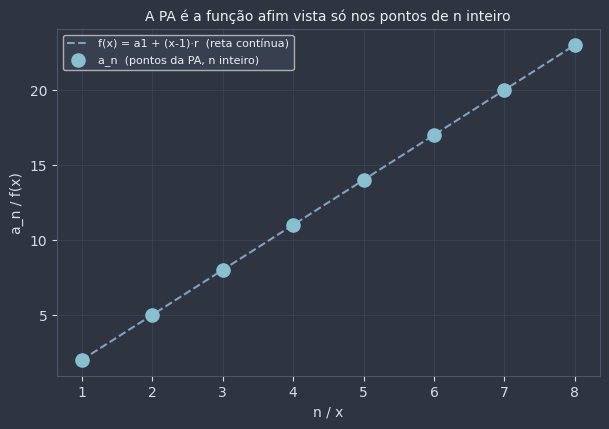

In [10]:
a1_afim, r_afim, n_afim = 2, 3, 8
indices_afim = np.arange(1, n_afim + 1)
termos_afim = gerar_pa(a1_afim, r_afim, n_afim)

x_continuo = np.linspace(1, n_afim, 200)
y_continuo = a1_afim + (x_continuo - 1) * r_afim

fig, ax = plt.subplots(figsize=(7, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(x_continuo, y_continuo, "--", color=COR_SECUNDARIA, linewidth=1.5, label="f(x) = a1 + (x-1)·r  (reta contínua)")
ax.scatter(indices_afim, termos_afim, s=90, color=COR_PONTO, zorder=3, label="a_n  (pontos da PA, n inteiro)")
ax.set_xlabel("n / x", color=NORD_TEXTO_SEC)
ax.set_ylabel("a_n / f(x)", color=NORD_TEXTO_SEC)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8)
ax.set_title("A PA é a função afim vista só nos pontos de n inteiro", color=NORD_TEXTO, fontsize=10)
plt.show()

**Pergunta de checagem:** qual é a "inclinação" (coeficiente angular) da reta que representa uma PA, em termos de r? E o que ela representa fisicamente, se aₙ fosse uma posição e n um tempo?

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| Progressão aritmética (PA) | sequência em que a diferença entre termos consecutivos é constante (razão r) |
| Lei recursiva | aₙ = aₙ₋₁ + r |
| Classificação | crescente (r > 0), decrescente (r < 0), constante (r = 0) — depende do sinal de r, não dos termos |
| PA de 3 termos | (x − r, x, x + r) |
| PA de 4 termos | (x − 3r, x − r, x + r, x + 3r) |
| Termo geral | aₙ = a₁ + (n − 1)·r |
| Interpolação de k meios | r = (aₙ − a₁) / (k + 1), com n = k + 2 |
| Soma dos n termos | Sₙ = (a₁ + aₙ)·n / 2 |
| Propriedade da média | aₙ = (aₙ₋₁ + aₙ₊₁) / 2; termo central = média de todos os termos (n ímpar) |
| PA × função afim | aₙ = a₁ + (n−1)r tem a forma f(x) = ax + b; a PA é a reta "vista" só em n inteiro |

## Exercícios

**Básico**
1. Calcular os termos de uma PA dada por a₁ e r, e classificá-la.
2. Calcular a soma dos termos de uma PA finita simples.

**Intermediário**
3. Interpolar meios aritméticos entre dois números.
4. Usar a notação de PA de 3 termos (e a propriedade da média) para resolver um problema com soma e produto conhecidos.

**Desafio**
5. Problema contextualizado: assentos de um teatro organizados em fileiras que crescem em PA.
6. Problema contextualizado: sistema de amortização SAC, em que os juros pagos formam uma PA decrescente.

Gabarito completo com resolução comentada em [`0302b_progressao_aritmetica_gabarito.ipynb`](0302b_progressao_aritmetica_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1: dada a PA com a1 = 4 e r = 5, calcule os 6
# primeiros termos (n de 1 a 6) e classifique-a quanto à razão. Preencha
# termos_ex1 com uma lista (ou array) dos 6 termos, e classificacao_ex1
# com uma das strings "crescente", "decrescente" ou "constante".
termos_ex1 = ...
classificacao_ex1 = ...

print(termos_ex1, classificacao_ex1)

In [ ]:
# Verificação
assert list(termos_ex1) == [4, 9, 14, 19, 24, 29], (
    "Tente de novo, revise: a_n = a1 + (n-1)*r, com a1=4 e r=5, para "
    "n=1,...,6 (seção 4 - Fórmula do Termo Geral)."
)
assert classificacao_ex1 == "crescente", (
    "Tente de novo, revise: a razão r=5 é positiva, então a PA é "
    "crescente (seção 2 - Classificação quanto à razão)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: uma PA tem a1 = 3, r = 4 e 15 termos (n = 15).
# Calcule o 15º termo em a15_ex2 e a soma dos 15 termos em soma_ex2.
a15_ex2 = ...
soma_ex2 = ...

print(a15_ex2, soma_ex2)

In [ ]:
# Verificação
assert a15_ex2 == 59, (
    "Tente de novo, revise: a_15 = a1 + (15-1)*r = 3 + 14*4 "
    "(seção 4 - Fórmula do Termo Geral)."
)
assert soma_ex2 == 465, (
    "Tente de novo, revise: S_15 = (a1 + a15)*15/2, usando o a15 já "
    "calculado (seção 6 - Soma dos Termos de uma PA Finita)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: interpole 4 meios aritméticos entre 6 e 26.
# Preencha pa_ex3 com a PA completa (os 2 extremos + os 4 meios, em
# ordem crescente de n), como lista ou array com 6 elementos.
pa_ex3 = ...

print(pa_ex3)

In [ ]:
# Verificação
assert list(pa_ex3) == [6, 10, 14, 18, 22, 26], (
    "Tente de novo, revise: com 4 meios entre 6 e 26, a PA final tem "
    "n=6 termos; r = (26-6)/(6-1) = 4 (seção 5 - Interpolação Aritmética)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4: três números em PA têm soma 24 e produto
# 384. Usando a notação (x-r, x, x+r), encontre os três números e
# preencha numeros_ex4 com uma lista de 3 elementos em ordem crescente.
numeros_ex4 = ...

print(numeros_ex4)

In [ ]:
# Verificação
assert sorted(numeros_ex4) == [4, 8, 12], (
    "Tente de novo, revise: com soma=3x, x=24/3=8; com produto="
    "x*(x^2-r^2)=384, isole r^2 e depois r (seção 3 - Notações Especiais)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: um teatro organiza seus assentos em fileiras.
# A primeira fileira tem 20 assentos, e cada fileira seguinte tem 4
# assentos a mais que a anterior. O setor tem 25 fileiras ao todo.
# Calcule quantos assentos tem a fileira 25 (assentos_fileira25_ex5) e
# quantos assentos tem o setor inteiro, somando todas as fileiras
# (total_assentos_ex5).
assentos_fileira25_ex5 = ...
total_assentos_ex5 = ...

print(assentos_fileira25_ex5, total_assentos_ex5)

In [ ]:
# Verificação
assert assentos_fileira25_ex5 == 116, (
    "Tente de novo, revise: a_25 = a1 + (25-1)*r = 20 + 24*4 "
    "(seção 4 - Fórmula do Termo Geral)."
)
assert total_assentos_ex5 == 1700, (
    "Tente de novo, revise: S_25 = (a1 + a25)*25/2, usando o valor de "
    "a25 já calculado (seção 6 - Soma dos Termos de uma PA Finita)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 6: um financiamento de R$ 12000 é pago em 10
# parcelas pelo sistema SAC simplificado: a amortização é constante,
# de R$ 1200 por parcela, e os juros de cada parcela são 2% sobre o
# saldo devedor ANTES daquela parcela (saldo antes da parcela n =
# 12000 - (n-1)*1200). Mostre que os juros pagos formam uma PA,
# calcule o total de juros pago nas 10 parcelas (total_juros_ex6) e o
# valor da última parcela = amortização + juros da parcela 10
# (ultima_parcela_ex6).
total_juros_ex6 = ...
ultima_parcela_ex6 = ...

print(total_juros_ex6, ultima_parcela_ex6)

In [ ]:
# Verificação
assert total_juros_ex6 == 1320, (
    "Tente de novo, revise: os juros formam uma PA com juros_1=240 e "
    "razão -24 (2% de -1200 de variação no saldo); "
    "some os 10 termos com S_n = (a1+a10)*n/2 (seção 6 - Soma dos "
    "Termos de uma PA Finita)."
)
assert ultima_parcela_ex6 == 1224, (
    "Tente de novo, revise: o juros da parcela 10 é a1 + 9*r = "
    "240 + 9*(-24) = 24; a última parcela é amortização (1200) + esse "
    "juros (seção 4 - Fórmula do Termo Geral)."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`0301a_sequencias.ipynb`](0301a_sequencias.ipynb) (sequência, termo geral, leis de formação explícita e recursiva)
- [`0107a_funcoes_primeiro_grau.ipynb`](../01_conjuntos_e_funcoes/0107a_funcoes_primeiro_grau.ipynb) (função afim)

**Isso será usado em:**
- 📌 Progressão Geométrica (para contraste PA × PG — razão aditiva × razão multiplicativa)
- 📌 Matemática Financeira (juros simples se apoia na mesma ideia de crescimento em PA)